# **1. Perkenalan Dataset**


# Telco Customer Churn Dataset

Dataset ini digunakan untuk memprediksi kemungkinan pelanggan berhenti menggunakan layanan telekomunikasi (customer churn).

Sumber dataset:
Telco Customer Churn Dataset

Target yang digunakan pada eksperimen ini adalah:

- Churn Value
    - 0 = Customer tidak churn
    - 1 = Customer churn

Tujuan eksperimen ini adalah melakukan eksplorasi data dan membangun pipeline preprocessing yang nantinya digunakan pada tahap pelatihan model machine learning.

# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_excel("Dataset_telco_customer_churn.xlsx")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# =====================================
# DATASET OVERVIEW
# =====================================

print("Dataset Shape:")
print(df.shape)

print("\n" + "="*50)
print("Data Types:")
print(df.dtypes)

print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\n" + "="*50)
print("Duplicate Rows:")
print(df.duplicated().sum())

print("\n" + "="*50)
print("Unique Values Per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Dataset Shape:
(7043, 33)

Data Types:
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtyp

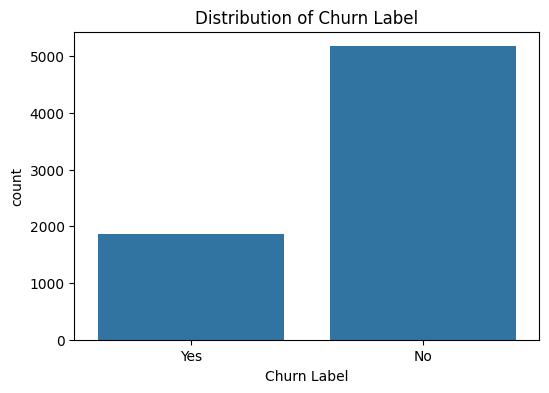

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [4]:
# =====================================
# TARGET DISTRIBUTION
# =====================================

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn Label"
)

plt.title("Distribution of Churn Label")
plt.show()

print(df["Churn Label"].value_counts())

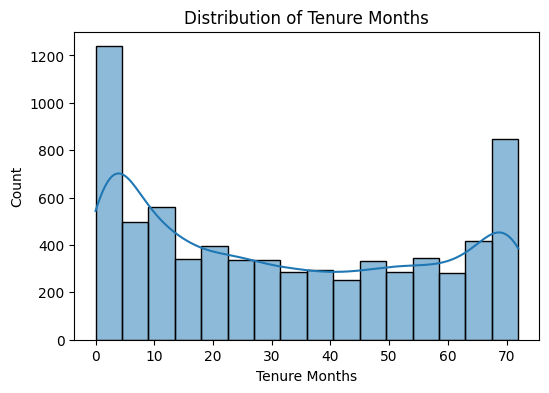

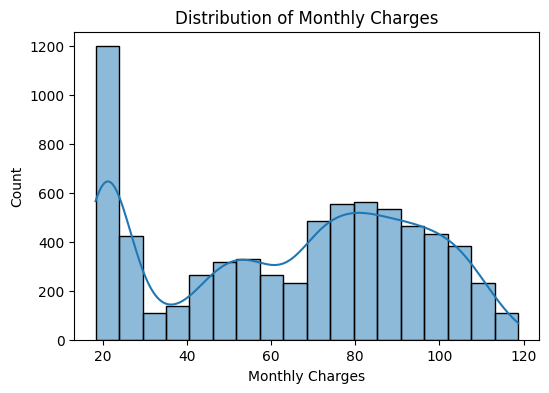

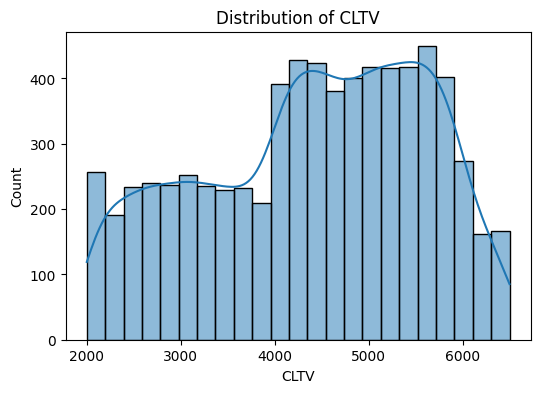

In [5]:
numerical_cols = [
    "Tenure Months",
    "Monthly Charges",
    "CLTV"
]

for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.show()

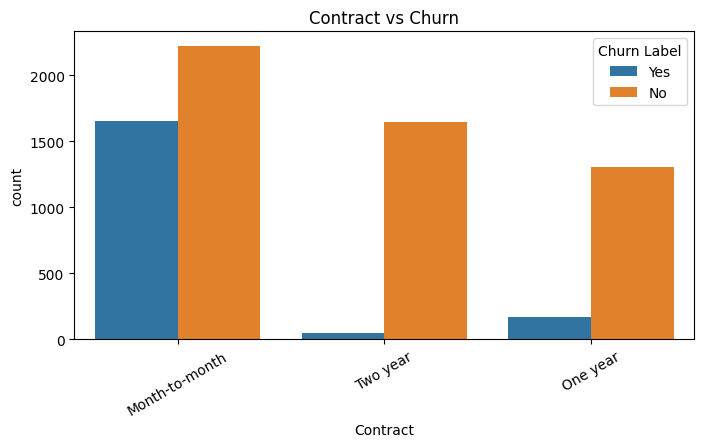

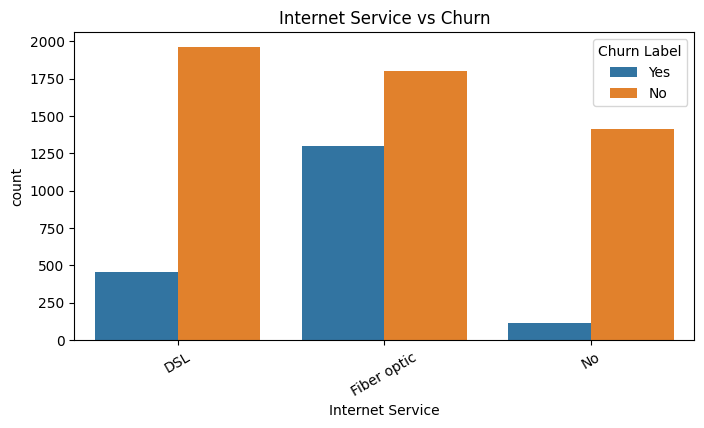

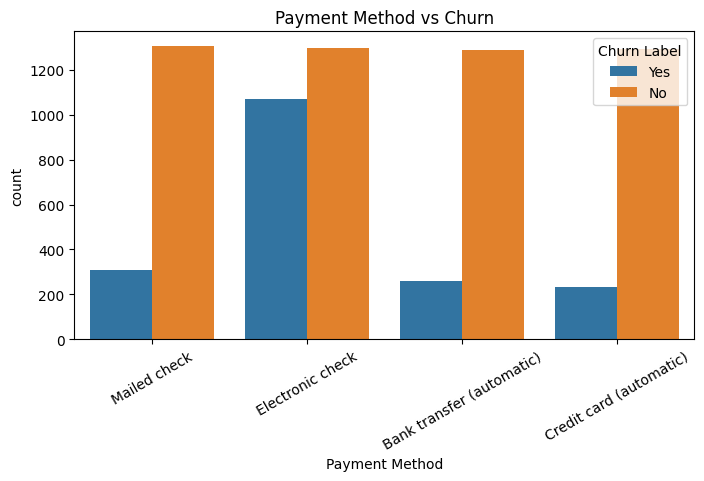

In [6]:
categorical_cols = [
    "Contract",
    "Internet Service",
    "Payment Method"
]

for col in categorical_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col,
        hue="Churn Label"
    )

    plt.xticks(rotation=30)

    plt.title(f"{col} vs Churn")

    plt.show()

In [7]:
df.groupby("Churn Value")["Churn Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,50.098183,17.702277,5.0,35.0,50.0,66.0,80.0
1,1869.0,82.510433,10.328570,65.0,74.0,82.0,91.0,100.0


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [8]:
# =====================================
# DATA PREPROCESSING
# =====================================

df_clean = df.copy()

columns_to_drop = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Reason',
    'Churn Score'
]

df_clean.drop(columns=columns_to_drop, inplace=True)

df_clean['Total Charges'] = pd.to_numeric(
    df_clean['Total Charges'],
    errors='coerce'
)

df_clean.dropna(inplace=True)

df_encoded = pd.get_dummies(
    df_clean,
    drop_first=True
)

scaler = StandardScaler()

numerical_cols = [
    'Tenure Months',
    'Monthly Charges',
    'Total Charges',
    'CLTV'
]

df_encoded[numerical_cols] = scaler.fit_transform(
    df_encoded[numerical_cols]
)

df_encoded.to_csv(
    "telco_preprocessed.csv",
    index=False
)

print("Preprocessing completed")
print("Final dataset shape:", df_encoded.shape)

df_encoded.head()

Preprocessing completed
Final dataset shape: (7032, 32)


,Tenure Months,Monthly Charges,Total Charges,Churn Value,CLTV,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,-1.239504,-0.363923,-0.959649,1,-0.983181,True,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True
1,-1.239504,0.196178,-0.940457,1,-1.438215,False,False,False,True,True,...,False,False,False,False,False,False,True,False,True,False
2,-0.995040,1.158489,-0.645369,1,0.820883,False,False,False,True,True,...,False,True,False,True,False,False,True,False,True,False
3,-0.180161,1.329677,0.336516,1,0.508788,False,False,True,True,True,...,False,True,False,True,False,False,True,False,True,False
4,0.675462,1.293113,1.214589,1,0.793818,True,False,False,True,True,...,False,True,False,True,False,False,True,False,False,False
